In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

https://onlinelibrary.wiley.com/doi/10.1155/2022/8124149

https://rubikscode.net/2021/09/06/stock-price-prediction-using-hidden-markov-model/



In [2]:
!pip install hmmlearn
from hmmlearn import hmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 3.3 MB/s eta 0:00:00


In [3]:
pip install yfinance pandas numpy hmmlearn plotly

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import requests
import pandas as pd
import numpy as np
from IPython.display import display
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn.hmm import GaussianHMM
import datetime
import yfinance as yf
from matplotlib.dates import MonthLocator
import itertools
from tqdm import tqdm
from hmmlearn.hmm import CategoricalHMM
from datetime import datetime, timedelta




# Experiment Here

https://www.kaggle.com/code/ehsanamim/stock-market-prediction-using-hmm

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import time
import requests
import io

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

In [6]:
data = yf.download("^GSPC", start="2000-01-01", end="2021-08-01")
data.shape



/tmp/ipykernel_13/3416645161.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2000-01-01", end="2021-08-01")
[*********************100%***********************]  1 of 1 completed


(5429, 5)

In [7]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [8]:
train_size = int(0.8*data.shape[0])
print(train_size)

4343


In [9]:
train_data = data.iloc[0:train_size]
train_data.columns = train_data.columns.droplevel(1)
test_data = data.iloc[train_size+1:]

In [10]:
def augment_features(dataframe):
    fracocp = (dataframe['Close'] - dataframe['Open']) / dataframe['Open']
    frachp = (dataframe['High'] - dataframe['Open']) / dataframe['Open']
    fraclp = (dataframe['Low'] - dataframe['Open']) / dataframe['Open']  # NO [/]()
    
    new_dataframe = pd.DataFrame({
        'delOpenClose': fracocp,
        'delHighOpen': frachp,
        'delLowOpen': fraclp
    })
    new_dataframe['price'] = (dataframe['High'] + dataframe['Low'] + dataframe['Close']) / 3
    new_dataframe['ret'] = dataframe['Close'].pct_change()
    new_dataframe['volatility'] = new_dataframe['ret'].rolling(window=10).std()
    new_dataframe['up'] = new_dataframe['ret'] > 0
    new_dataframe['down'] = new_dataframe['ret'] < 0
    #new_dataframe.dropna(inplace=True)
    return new_dataframe

In [11]:
def extract_features(dataframe):
    return np.column_stack((dataframe['delOpenClose'], dataframe['delHighOpen'], dataframe['delLowOpen']))

In [12]:
print("train_data shape:", train_data.shape)
print("train_data columns:", train_data.columns.tolist())
print("train_data head:\n", train_data.head())

aug_data = augment_features(train_data)
print("\naug_data shape:", aug_data.shape)
print("aug_data NaN count:\n", aug_data.isnull().sum())
print("aug_data head:\n", aug_data.head())



train_data shape: (4343, 5)
train_data columns: ['Close', 'High', 'Low', 'Open', 'Volume']
train_data head:
 Price             Close         High          Low         Open      Volume
Date                                                                      
2000-01-03  1455.219971  1478.000000  1438.359985  1469.250000   931800000
2000-01-04  1399.420044  1455.219971  1397.430054  1455.219971  1009000000
2000-01-05  1402.109985  1413.270020  1377.680054  1399.420044  1085500000
2000-01-06  1403.449951  1411.900024  1392.099976  1402.109985  1092300000
2000-01-07  1441.469971  1441.469971  1400.729980  1403.449951  1225200000

aug_data shape: (4343, 8)
aug_data NaN count:
 delOpenClose     0
delHighOpen      0
delLowOpen       0
price            0
ret              1
volatility      10
up               0
down             0
dtype: int64
aug_data head:
             delOpenClose  delHighOpen  delLowOpen        price       ret  \
Date                                                         

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [13]:
features = extract_features(augment_features(train_data))

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


In [14]:
features.shape

(4343, 3)

In [15]:
model = GaussianHMM(n_components=10)

In [16]:
feature_train_data = augment_features(train_data)
features_train = extract_features(feature_train_data)
model.fit(features_train)

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


GaussianHMM(n_components=10)

# NASDAQ

https://github.com/IanQuan/Hidden-Markov-Model-on-Stock-Price-Prediction

https://blog.quantinsti.com/regime-adaptive-trading-python/

In [17]:
symbol = "^IXIC"
data = yf.download(symbol, start="2021-09-01", end=datetime.datetime.now())

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

train_days = 252  
test_start_idx = len(data) - 100  
train_data = data.iloc[max(0, test_start_idx - train_days):test_start_idx]
test_data = data.iloc[test_start_idx:]

/tmp/ipykernel_13/2560170190.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2021-09-01", end=datetime.datetime.now())
[*********************100%***********************]  1 of 1 completed


In [18]:
def augment_features(df):
    df = df.copy()

    out = pd.DataFrame({
        "delOpenClose": (df["Close"] - df["Open"]) / df["Open"],
        "delHighOpen":  (df["High"] - df["Open"]) / df["Open"],
        "delLowOpen":   (df["Low"]  - df["Open"])  / df["Open"],
    })

    out["price"] = (df["High"] + df["Low"] + df["Close"]) / 3
    out["ret"] = df["Close"].pct_change()

    out = out.dropna()
    return out

In [19]:
def extract_features(df):
    return df[["delOpenClose", "delHighOpen", "delLowOpen"]].values

In [20]:
aug_train = augment_features(train_data)
X_train = extract_features(aug_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [21]:
model = GaussianHMM(
    n_components=5,
    covariance_type="full",
    n_iter=300,
    min_covar=1e-3,
    random_state=42,
)

model.fit(X_train_scaled)

GaussianHMM(covariance_type='full', n_components=5, n_iter=300, random_state=42)

In [22]:
aug_test = augment_features(test_data)
test_feat = extract_features(aug_test)
test_feat_scaled = scaler.transform(test_feat)

f1 = test_feat_scaled[:, 0]
f2 = test_feat_scaled[:, 1]
f3 = test_feat_scaled[:, 2]

sample_space = np.array(list(itertools.product(
    np.linspace(f1.min(), f1.max(), 30),
    np.linspace(f2.min(), f2.max(), 10),
    np.linspace(f3.min(), f3.max(), 10),
)))

In [23]:
num_latent_days = 30
num_days_to_predict = 200

In [24]:
test_data_reset = test_data.reset_index(drop=True)
predicted_close_prices = []

In [25]:
max_steps = min(num_days_to_predict, len(test_data_reset))
for i in tqdm(range(max_steps)):
    start_idx = max(0, i - num_latent_days)
    window_df = test_data_reset.iloc[start_idx:i]

    if len(window_df) < 5:
        predicted_close_prices.append(np.nan)
        continue

    window_feat = extract_features(augment_features(window_df))
    window_feat_scaled = scaler.transform(window_feat)

    scores = [
        model.score(np.vstack([window_feat_scaled, s.reshape(1, -1)]))
        for s in sample_space
    ]

    best_idx = int(np.argmax(scores))
    best = sample_space[best_idx]
    best_original = scaler.inverse_transform(best.reshape(1, -1))[0]

    open_price = float(test_data_reset.iloc[i]["Open"])
    predicted_close = open_price * (1 + best_original[0])
    predicted_close_prices.append(predicted_close)

100%|██████████| 100/100 [03:26<00:00,  2.06s/it]


In [26]:
# Plot last 100 days
last_100_days = data.tail(100)
test_index_100 = last_100_days.index

In [27]:
min_len = min(len(predicted_close_prices), len(test_index_100))
pred_series = pd.Series(
    predicted_close_prices[:min_len],
    index=test_index_100[:min_len],
)

In [28]:
actual_series = last_100_days["Close"].iloc[:min_len]

valid_mask = (~pred_series.isna()) & (~actual_series.isna())
actual_clean = actual_series[valid_mask]
pred_clean = pred_series[valid_mask]

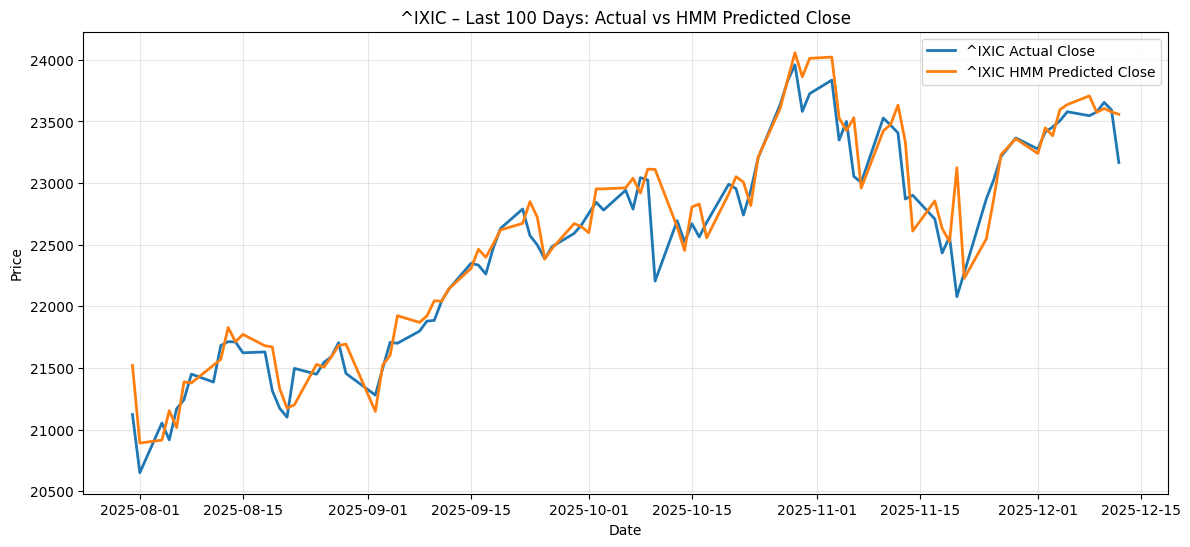

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(actual_clean.index, actual_clean.values,
         label=f"{symbol} Actual Close", linewidth=2)
plt.plot(pred_clean.index, pred_clean.values,
         label=f"{symbol} HMM Predicted Close", linewidth=2)
plt.title(f"{symbol} – Last 100 Days: Actual vs HMM Predicted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [30]:
actual_vals = actual_clean.values
pred_vals = pred_clean.values
mape = np.mean(np.abs((actual_vals - pred_vals) / actual_vals)) * 100
print(f"Model 1 – {symbol} MAPE: {mape:.2f}%")

Model 1 – ^IXIC MAPE: 0.65%


# Forex

https://www.marketcalls.in/python/introduction-to-hidden-markov-models-hmm-for-traders-python-tutorial.html\

https://users.cs.duke.edu/~bdhingra/papers/stock_hmm.pdf

In [31]:
#https://scholar.tecnico.ulisboa.pt/api/records/WuxQcfRb824vpZzuCEkB0TjOBMcIxDn-VdYQ/file/7dce27523655b649f28d694c9305bc6c79935e25234aba9f92be53a87d32dc31.pdf

symbol = "JPY=X"

data = yf.download(symbol, start="2025-09-01", end=datetime.datetime.now())

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[["Open", "High", "Low", "Close"]].dropna()

train_size = int(0.8 * len(data))
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

/tmp/ipykernel_13/664286905.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2025-09-01", end=datetime.datetime.now())
[*********************100%***********************]  1 of 1 completed


In [32]:
#feature engineering
def augment_features_fx(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df["log_ret"] = np.log(df["Close"]).diff()
    df["range_high_low"] = (df["High"] - df["Low"]) / df["Open"]
    df["range_close_open"] = (df["Close"] - df["Open"]) / df["Open"]

    df = df.dropna()

    return df

In [33]:
def extract_features_fx(df: pd.DataFrame) -> np.ndarray:
    return df[["log_ret", "range_high_low", "range_close_open"]].values

In [34]:
aug_train = augment_features_fx(train_data)
X_train = extract_features_fx(aug_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [35]:
model = GaussianHMM(
    n_components=4,          
    covariance_type="full",
    n_iter=300,
    min_covar=1e-3,
    random_state=42
)

model.fit(X_train_scaled)

train_states = model.predict(X_train_scaled)

Model is not converging.  Current: 36.27540189324722 is not greater than 37.22677094463083. Delta is -0.9513690513836082


In [36]:
regime_mean_logret = []

for s in range(model.n_components):
    mask = (train_states == s)
    if mask.sum() == 0:
        mu = 0.0
    else:
        mu = aug_train["log_ret"].iloc[mask].mean()
    regime_mean_logret.append(mu)

regime_mean_logret = np.array(regime_mean_logret)

In [37]:
aug_all = augment_features_fx(data)
X_all = extract_features_fx(aug_all)
X_all_scaled = scaler.transform(X_all)

all_states = model.predict(X_all_scaled)

In [38]:
actual_close = data["Close"].loc[aug_all.index] 
predicted_close = []

for i in range(len(aug_all) - 1):
    current_state = all_states[i]
    mu_log_ret = regime_mean_logret[current_state]
    next_price = actual_close.iloc[i] * np.exp(mu_log_ret)
    predicted_close.append(next_price)

In [39]:
pred_index = actual_close.index[1:]
pred_series = pd.Series(predicted_close, index=pred_index)
actual_series = actual_close.iloc[1:]

In [40]:
N_forecast = 60
last_price = data["Close"].iloc[-1]
last_state = all_states[-1]

In [41]:
forecast_prices = []
forecast_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1),
                               periods=N_forecast, freq="D")

In [42]:
for _ in range(N_forecast):
    trans_probs = model.transmat_[last_state]
    expected_log_ret = np.dot(trans_probs, regime_mean_logret)

    next_price = last_price * np.exp(expected_log_ret)
    forecast_prices.append(next_price)

    last_state = np.argmax(trans_probs)
    last_price = next_price

forecast_series = pd.Series(forecast_prices, index=forecast_dates)

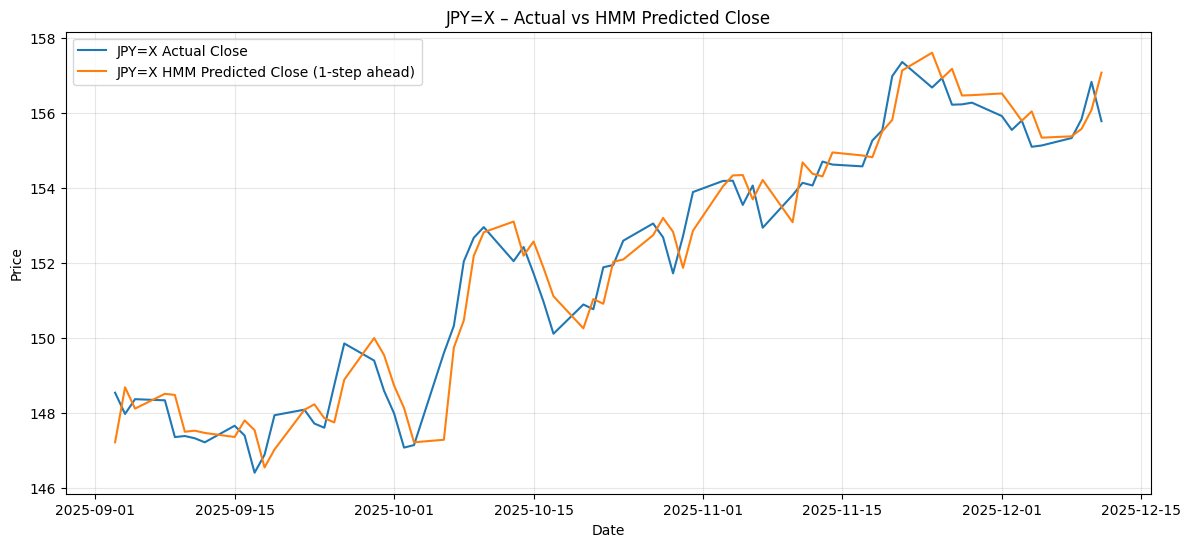

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(actual_series.index, actual_series.values,
         label=f"{symbol} Actual Close")
plt.plot(pred_series.index, pred_series.values,
         label=f"{symbol} HMM Predicted Close (1-step ahead)")

plt.title(f"{symbol} – Actual vs HMM Predicted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [44]:
actual_vals = actual_series.dropna().values
pred_vals = pred_series.dropna().values
min_len = min(len(actual_vals), len(pred_vals))
mape = np.mean(np.abs((actual_vals[:min_len] - pred_vals[:min_len]) / actual_vals[:min_len])) * 100
print(f"Model 2 – {symbol} MAPE: {mape:.2f}%")

Model 2 – JPY=X MAPE: 0.39%


# Ethereum

[https://www.kaggle.com/code/hassanoukhouya/a-hidden-markov-model-hmm-for-predicting-bitcoin](http://)

https://github.com/Nikhil-Kumar-Patel/Hidden-Makov-Model



In [45]:
def fetch_daily_data(symbol="ETH-USD", days=3650):
    end_date = datetime.datetime.now()
    start_date = end_date - timedelta(days=days)
    data = yf.download(symbol, start=start_date, end=end_date, interval="1d")
    
    # Flatten here
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data

In [46]:
def discretize_returns(log_ret, num_bins=7):
    bins = pd.qcut(log_ret, q=num_bins, labels=False, retbins=True, duplicates='drop')[1]
    codes = pd.cut(log_ret, bins=bins, labels=False, include_lowest=True)
    return codes, bins

In [47]:
def fit_categorical_hmm(observations, n_components=3):
    model = CategoricalHMM(n_components=n_components, n_iter=300, random_state=42)
    model.fit(observations.reshape(-1, 1))
    hidden_states = model.predict(observations.reshape(-1, 1))
    return model, hidden_states

In [48]:
def regimes_to_signals(hidden_states, log_ret):
    regimes = pd.Series(hidden_states, index=log_ret.index)
    mean_by_state = {}
    for s in np.unique(hidden_states):
        mask = hidden_states == s
        mean_by_state[s] = log_ret[mask].mean()
    signals = pd.Series([mean_by_state[s] for s in hidden_states], index=log_ret.index)
    return regimes, signals, mean_by_state

In [49]:
def compute_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["log_ret"] = np.log(df["Close"]).diff()
    df = df.dropna()
    return df

In [50]:
symbol = "ETH-USD"
data = fetch_daily_data(symbol, days=100)

df_ret = compute_log_returns(data)
log_ret = df_ret["log_ret"]
close_series = df_ret["Close"].squeeze()

codes, bins = discretize_returns(log_ret, num_bins=7)
model, hidden_states = fit_categorical_hmm(codes.to_numpy(), n_components=3)

regimes, signals, mean_by_state = regimes_to_signals(hidden_states, log_ret)

/tmp/ipykernel_13/2685051787.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start=start_date, end=end_date, interval="1d")
[*********************100%***********************]  1 of 1 completed


In [51]:
states = np.sort(list(mean_by_state.keys()))
mu = np.array([mean_by_state[s] for s in states])

In [52]:
n = len(regimes)
states_seq = regimes.to_numpy()

pred_prices = []
pred_index = []

In [53]:

for i in range(n - 1):
    state_i = states_seq[i]
    mu_i = mean_by_state[state_i]      # expected log-return given current state
    next_price = close_series.iloc[i] * np.exp(mu_i)
    pred_prices.append(next_price)
    pred_index.append(close_series.index[i + 1])  # prediction for next day

pred_series = pd.Series(pred_prices, index=pred_index, name="Predicted_Close")
actual_series = close_series.loc[pred_series.index]

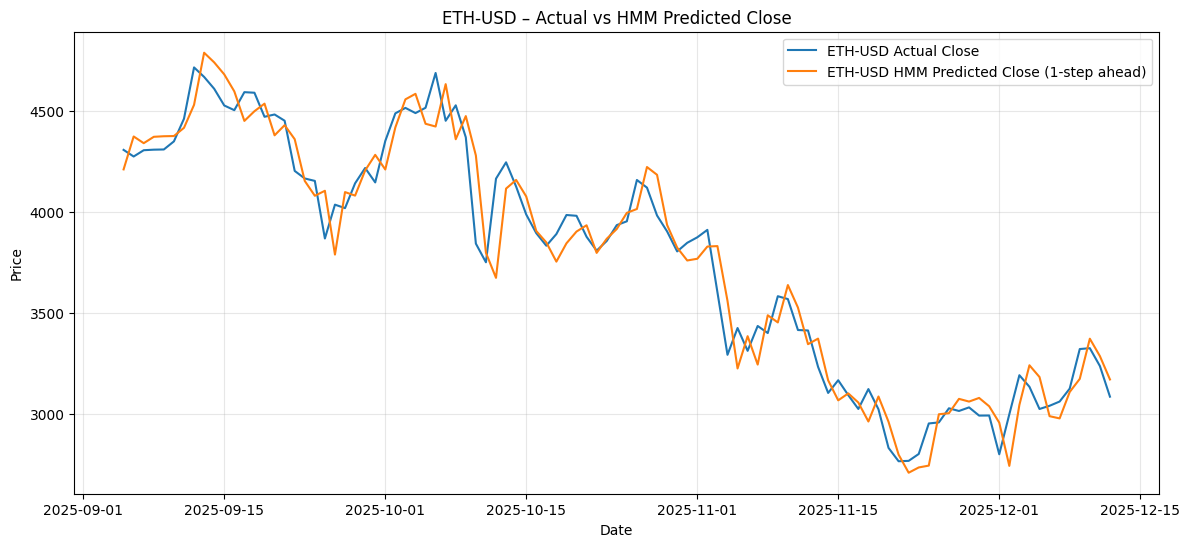

In [54]:
plt.figure(figsize=(14, 6))

plt.plot(actual_series.index, actual_series.values,
         label=f"{symbol} Actual Close")
plt.plot(pred_series.index, pred_series.values,
         label=f"{symbol} HMM Predicted Close (1-step ahead)")

plt.title(f"{symbol} – Actual vs HMM Predicted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [55]:
actual_vals = actual_series.dropna().values
pred_vals = pred_series.dropna().values
min_len = min(len(actual_vals), len(pred_vals))
mape = np.mean(np.abs((actual_vals[:min_len] - pred_vals[:min_len]) / actual_vals[:min_len])) * 100
print(f"Model 3 – {symbol} MAPE: {mape:.2f}%")

Model 3 – ETH-USD MAPE: 2.79%


# My Implementation

In [56]:
#My own implementation

# Basic HMM stock example on Microsoft (MSFT)

def fetch_daily_data(symbol="MSFT", days=3650):
    end_date = datetime.datetime.now()
    start_date = end_date - timedelta(days=days)
    data = yf.download(symbol, start=start_date, end=end_date, interval="1d")
    
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data

In [57]:
def compute_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["log_ret"] = np.log(df["Close"]).diff()
    df = df.dropna()
    return df

In [58]:
def fit_gaussian_hmm(log_ret: pd.Series, n_components: int = 3):
    X = log_ret.to_numpy().reshape(-1, 1)   
    model = GaussianHMM(
        n_components=n_components,
        covariance_type="full",
        n_iter=200,
        random_state=42
    )
    model.fit(X)
    hidden_states = model.predict(X)
    return model, hidden_states

In [59]:
def regimes_and_means(hidden_states: np.ndarray, log_ret: pd.Series):
    n = min(len(hidden_states), len(log_ret))
    hidden_states = hidden_states[:n]
    log_ret = log_ret.iloc[:n]

    states = np.unique(hidden_states)
    mean_by_state = {}
    for s in states:
        mask = (hidden_states == s)
        mean_by_state[s] = log_ret.iloc[mask].mean()

    regimes = pd.Series(hidden_states, index=log_ret.index)
    return regimes, mean_by_state

In [60]:
symbol = "MSFT"
data = fetch_daily_data(symbol, days=100)

df_ret = compute_log_returns(data)
log_ret = df_ret["log_ret"]
close_series = df_ret["Close"]

model, hidden_states = fit_gaussian_hmm(log_ret, n_components=3)
regimes, mean_by_state = regimes_and_means(hidden_states, log_ret)

/tmp/ipykernel_13/1832719019.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start=start_date, end=end_date, interval="1d")
[*********************100%***********************]  1 of 1 completed


In [61]:
model, hidden_states = fit_gaussian_hmm(log_ret, n_components=3)
regimes, mean_by_state = regimes_and_means(hidden_states, log_ret)

In [62]:
states_seq = regimes.to_numpy()
n = len(regimes)

pred_prices = []
pred_index = []

for i in range(n - 1):
    s_i = states_seq[i]
    mu_i = mean_by_state[s_i]    
    next_price = close_series.iloc[i] * np.exp(mu_i)
    pred_prices.append(next_price)
    pred_index.append(close_series.index[i + 1])

pred_series = pd.Series(pred_prices, index=pred_index, name="Predicted_Close")
actual_series = close_series.loc[pred_series.index]

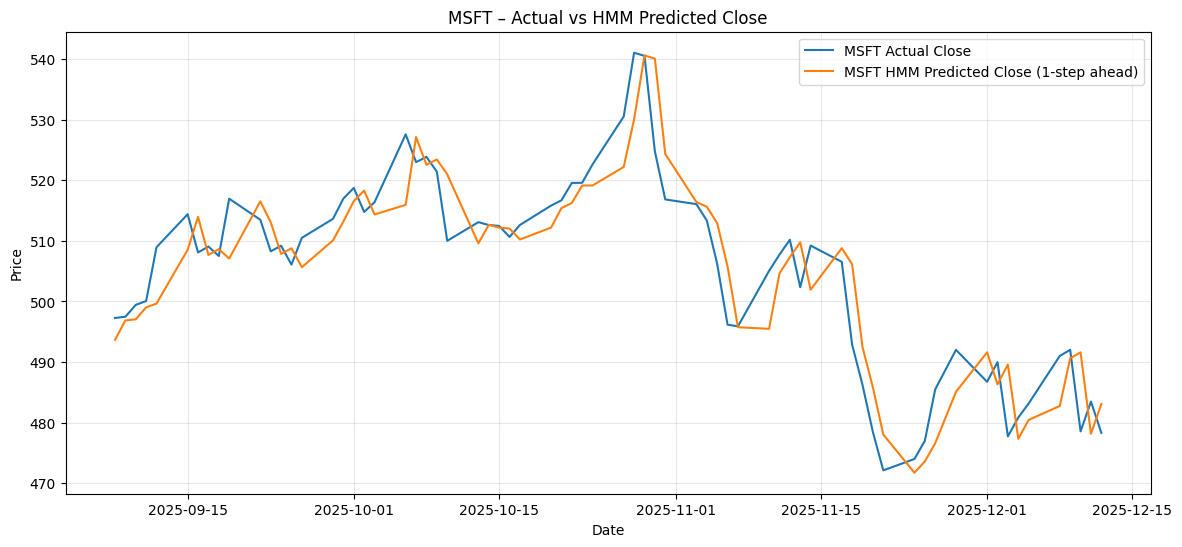

In [63]:
plt.figure(figsize=(14, 6))

plt.plot(actual_series.index, actual_series.values,
         label=f"{symbol} Actual Close")
plt.plot(pred_series.index, pred_series.values,
         label=f"{symbol} HMM Predicted Close (1-step ahead)")

plt.title(f"{symbol} – Actual vs HMM Predicted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [64]:
actual_vals = actual_series.dropna().values
pred_vals = pred_series.dropna().values
min_len = min(len(actual_vals), len(pred_vals))
mape = np.mean(np.abs((actual_vals[:min_len] - pred_vals[:min_len]) / actual_vals[:min_len])) * 100
print(f"Model 4 – {symbol} MAPE: {mape:.2f}%")

Model 4 – MSFT MAPE: 0.95%
